In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


### *importing dataset

In [2]:

df=pd.read_csv("matches.csv")
df.head()

In [3]:
data.shape

NameError: name 'data' is not defined

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 26 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1024 non-null   int64  
 1   date             1024 non-null   object 
 2   season           1024 non-null   object 
 3   event_name       1024 non-null   object 
 4   match_type       1024 non-null   object 
 5   match_number     1024 non-null   object 
 6   city             973 non-null    object 
 7   venue            1024 non-null   object 
 8   team1            1024 non-null   object 
 9   team2            1024 non-null   object 
 10  referee          1024 non-null   object 
 11  reserve_umpire   1000 non-null   object 
 12  tv_umpire        1021 non-null   object 
 13  umpire1          1024 non-null   object 
 14  umpire2          1024 non-null   object 
 15  team1players     1024 non-null   object 
 16  team2players     1024 non-null   object 
 17  toss_winner   

In [ ]:
df.columns

Index(['id', 'date', 'season', 'event_name', 'match_type', 'match_number',
       'city', 'venue', 'team1', 'team2', 'referee', 'reserve_umpire',
       'tv_umpire', 'umpire1', 'umpire2', 'team1players', 'team2players',
       'toss_winner', 'toss_decision', 'winner', 'result', 'eliminator',
       'wonBy', 'margin', 'method', 'player_of_match'],
      dtype='object')

### checking for not a number values

In [ ]:
df.isna().any()  

id                 False
date               False
season             False
event_name         False
match_type         False
match_number       False
city                True
venue              False
team1              False
team2              False
referee            False
reserve_umpire      True
tv_umpire           True
umpire1            False
umpire2            False
team1players       False
team2players       False
toss_winner        False
toss_decision      False
winner              True
result              True
eliminator          True
wonBy               True
margin              True
method              True
player_of_match     True
dtype: bool

In [ ]:
df.describe()

,id,margin
count,1.024000e+03,1005.000000
mean,8.687579e+05,17.215920
std,3.528920e+05,21.791299
min,3.359820e+05,1.000000
25%,5.483138e+05,6.000000
50%,8.298140e+05,8.000000
75%,1.216503e+06,19.000000
max,1.370353e+06,146.000000


### total number of matches played

In [ ]:
df['id'].count()  

np.int64(1024)

In [ ]:
df['season'].unique()

array(['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022',
       '2023'], dtype=object)

### which ipl team won by scoring maximum runs

In [ ]:
df.iloc[df['margin'].idxmax()] 

id                                                           1082635
date                                                      06-05-2017
season                                                          2017
event_name                                     Indian Premier League
match_type                                                       T20
match_number                                                      45
city                                                           Delhi
venue                                               Feroz Shah Kotla
team1                                               Delhi Daredevils
team2                                                 Mumbai Indians
referee                                                 ['M Nayyar']
reserve_umpire                                      ['K Srinivasan']
tv_umpire                                               ['YC Barde']
umpire1                                                  Nitin Menon
umpire2                           

### which Season consist of highest number of matches ever played

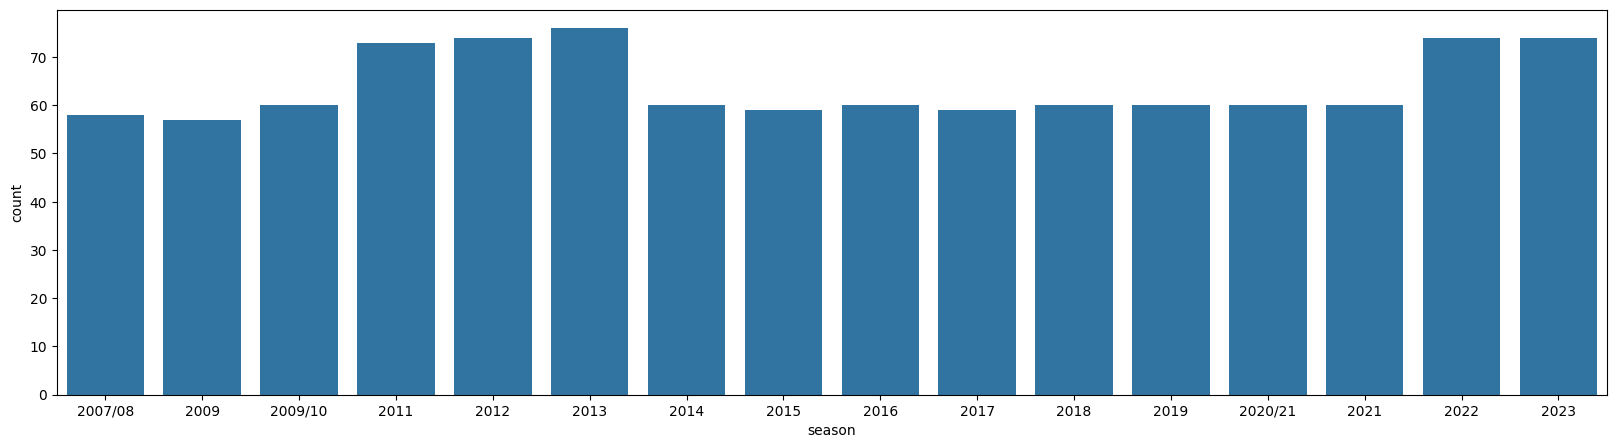

In [ ]:

fig_dims=(20,5)
fig , ax=plt.subplots(figsize=fig_dims)
sns.countplot(x='season',ax=ax ,data=df)
plt.show()

### *which is the most sucessful team in IPL till now


In [ ]:
df1=df.winner.value_counts()
df1

winner
Mumbai Indians                 138
Chennai Super Kings            131
Kolkata Knight Riders          119
Royal Challengers Bangalore    114
Rajasthan Royals               101
Kings XI Punjab                 85
Sunrisers Hyderabad             78
Delhi Daredevils                67
Delhi Capitals                  38
Deccan Chargers                 29
Gujarat Titans                  23
Punjab Kings                    19
Lucknow Super Giants            17
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='winner'>

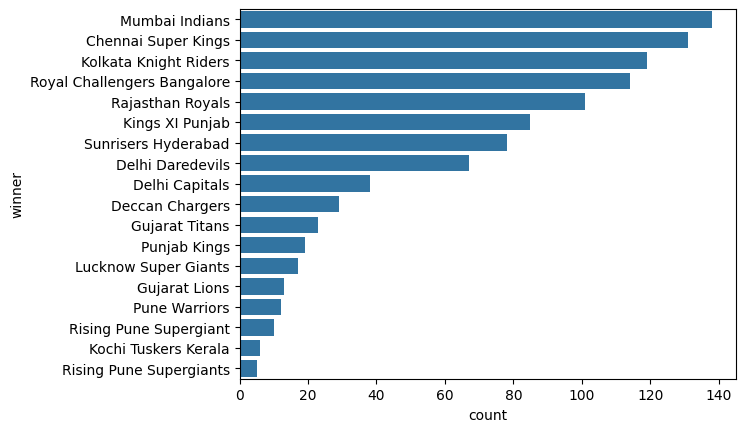

In [ ]:
sns.barplot(y=df1.index, x=df1)

### what is the probaility of winnig a match if the toss is won

In [ ]:

probability_of_win =df['toss_winner']==df['winner']
result=probability_of_win.groupby(probability_of_win).size()
print(result)   

False    507
True     517
dtype: int64


<Axes: >

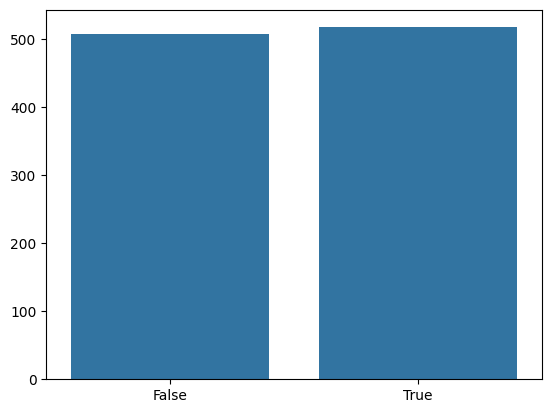

In [ ]:

sns.barplot(result)

### *highest win by team per season

In [ ]:

df.groupby('season')['winner'].value_counts()

season   winner                     
2007/08  Rajasthan Royals               13
         Kings XI Punjab                10
         Chennai Super Kings             9
         Delhi Daredevils                7
         Mumbai Indians                  7
                                        ..
2023     Royal Challengers Bangalore     7
         Kolkata Knight Riders           6
         Punjab Kings                    6
         Delhi Capitals                  5
         Sunrisers Hyderabad             4
Name: count, Length: 136, dtype: int64

In [ ]:
df['toss_decision'].value_counts()

toss_decision
field    652
bat      372
Name: count, dtype: int64

### *top 10 Man of the match winner

In [ ]:
df['player_of_match'].value_counts()[0:10]  

player_of_match
['AB de Villiers']    25
['CH Gayle']          22
['RG Sharma']         19
['DA Warner']         18
['MS Dhoni']          17
['V Kohli']           16
['YK Pathan']         16
['SR Watson']         16
['KA Pollard']        14
['RA Jadeja']         14
Name: count, dtype: int64

In [ ]:
list(df['player_of_match'].value_counts()[0:5].keys())

["['AB de Villiers']",
 "['CH Gayle']",
 "['RG Sharma']",
 "['DA Warner']",
 "['MS Dhoni']"]

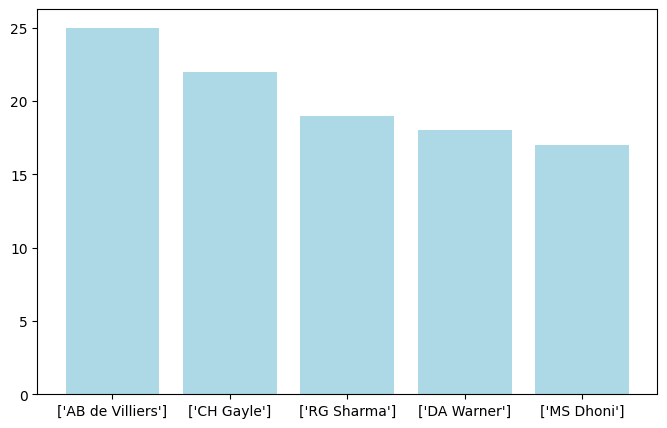

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(list(df['player_of_match'].value_counts()[0:5].keys()),list(data['player_of_match'].value_counts()[0:5
                                                                                                             ]),color='lightblue')
plt.show()

### *top 10 most played match stadiums

In [ ]:
df['city'].value_counts()[0:10]  

city
Mumbai        166
Kolkata        86
Delhi          85
Chennai        76
Hyderabad      71
Bangalore      65
Chandigarh     61
Jaipur         52
Pune           51
Abu Dhabi      37
Name: count, dtype: int64

### *getting the frequency of result column

In [ ]:
df['result'].value_counts() 

result
tie          14
no result     5
Name: count, dtype: int64

In [ ]:
df['toss_winner'].value_counts()

toss_winner
Mumbai Indians                 133
Chennai Super Kings            119
Kolkata Knight Riders          119
Royal Challengers Bangalore    113
Rajasthan Royals               109
Kings XI Punjab                 85
Sunrisers Hyderabad             81
Delhi Daredevils                80
Delhi Capitals                  43
Deccan Chargers                 43
Pune Warriors                   20
Gujarat Titans                  19
Gujarat Lions                   15
Punjab Kings                    14
Lucknow Super Giants            10
Kochi Tuskers Kerala             8
Rising Pune Supergiants          7
Rising Pune Supergiant           6
Name: count, dtype: int64

### *records where team won batting first

In [ ]:

batting_first=df[df['result']=='runs']
batting_first.head()

,id,date,season,event_name,match_type,match_number,city,venue,team1,team2,...,team2players,toss_winner,toss_decision,winner,result,eliminator,wonBy,margin,method,player_of_match


(463, 26)


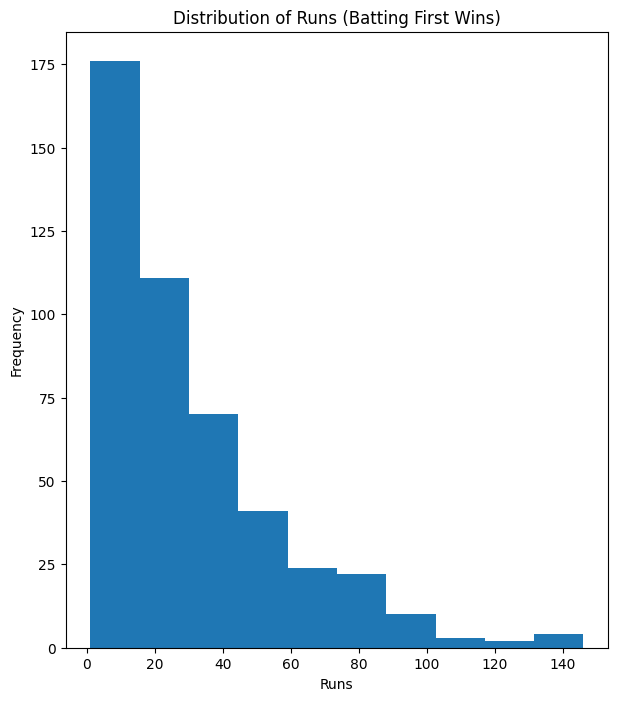

In [ ]:
import matplotlib.pyplot as plt

df['wonBy'] = df['wonBy'].str.strip().str.lower()

batting_first = df[df['wonBy'] == 'runs']

print(batting_first.shape)  # should NOT be 0

plt.figure(figsize=(7,8))
plt.hist(batting_first['margin'])
plt.title("Distribution of Runs (Batting First Wins)")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show()

### *finding out the teams registered wins after batting first

In [ ]:
batting_first['winner'].value_counts()

winner
Mumbai Indians                 69
Chennai Super Kings            67
Royal Challengers Bangalore    53
Kolkata Knight Riders          48
Rajasthan Royals               41
Kings XI Punjab                40
Sunrisers Hyderabad            38
Delhi Daredevils               25
Deccan Chargers                18
Delhi Capitals                 16
Lucknow Super Giants           12
Punjab Kings                   11
Gujarat Titans                  9
Pune Warriors                   6
Rising Pune Supergiant          5
Kochi Tuskers Kerala            2
Rising Pune Supergiants         2
Gujarat Lions                   1
Name: count, dtype: int64

### *bar-plot for top 3 teams won after deciding bat first

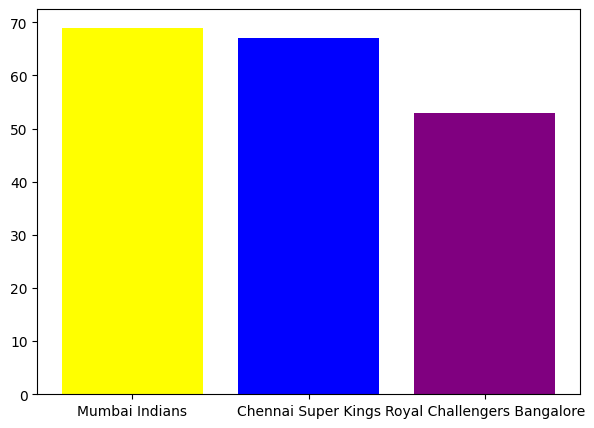

In [ ]:
plt.figure(figsize=(7,5))  
plt.bar(list(batting_first['winner'].value_counts()[0:3].keys()), list(batting_first['winner'].value_counts()[0:3]), color=['yellow','blue','purple'])
plt.show()

### *Pie chart of teams won by batting first

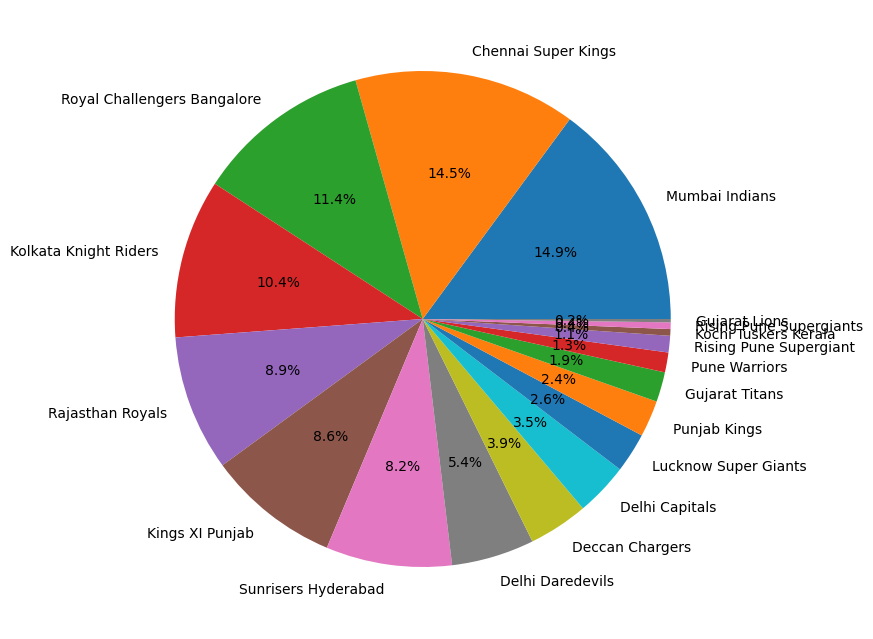

In [ ]:
plt.figure(figsize=(8,10))  
plt.pie(list(batting_first['winner'].value_counts()),labels= list(batting_first['winner'].value_counts().keys()), autopct='%0.1f%%')
plt.show()

### *teams won after batting second and won by number of wickets

In [ ]:
batting_second=df[df['result']=='wickets']
batting_second.head()

,id,date,season,event_name,match_type,match_number,city,venue,team1,team2,...,team2players,toss_winner,toss_decision,winner,result,eliminator,wonBy,margin,method,player_of_match


### *histogram plot

(542, 26)


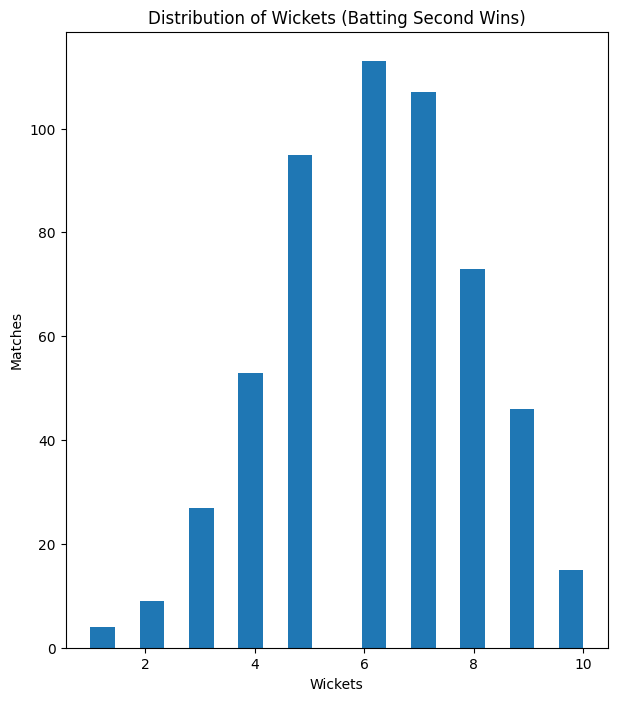

In [ ]:
df['wonBy'] = df['wonBy'].str.strip().str.lower()

batting_second = df[df['wonBy'] == 'wickets']

print(batting_second.shape)  

plt.figure(figsize=(7,8))
plt.hist(batting_second['margin'], bins=20)
plt.title("Distribution of Wickets (Batting Second Wins)")
plt.xlabel("Wickets")
plt.ylabel("Matches")
plt.show()

In [ ]:
batting_second['winner'].value_counts()

winner
Kolkata Knight Riders          71
Mumbai Indians                 69
Chennai Super Kings            64
Royal Challengers Bangalore    61
Rajasthan Royals               60
Kings XI Punjab                45
Delhi Daredevils               42
Sunrisers Hyderabad            40
Delhi Capitals                 22
Gujarat Titans                 14
Gujarat Lions                  12
Deccan Chargers                11
Punjab Kings                    8
Pune Warriors                   6
Lucknow Super Giants            5
Rising Pune Supergiant          5
Kochi Tuskers Kerala            4
Rising Pune Supergiants         3
Name: count, dtype: int64

### *top 3 teams

<BarContainer object of 3 artists>

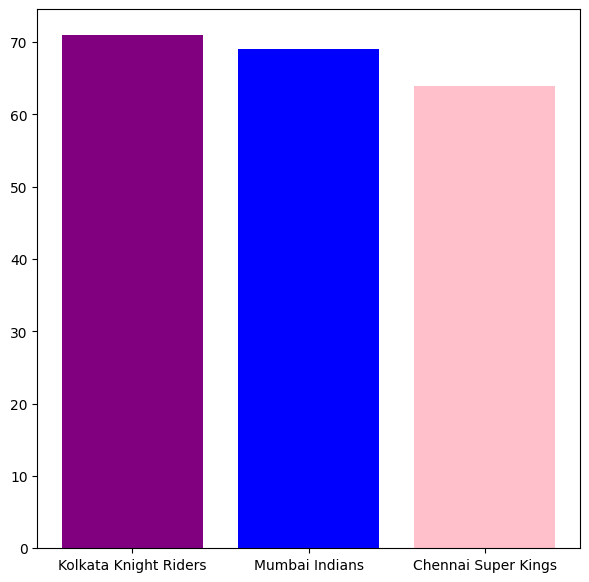

In [ ]:
plt.figure(figsize=(7,7))   
plt.bar(list(batting_second['winner'].value_counts()[0:3].keys()), list(batting_second['winner'].value_counts()[0:3]), color=['purple','blue','pink'])

### *Pie chart of teams that won by batting second

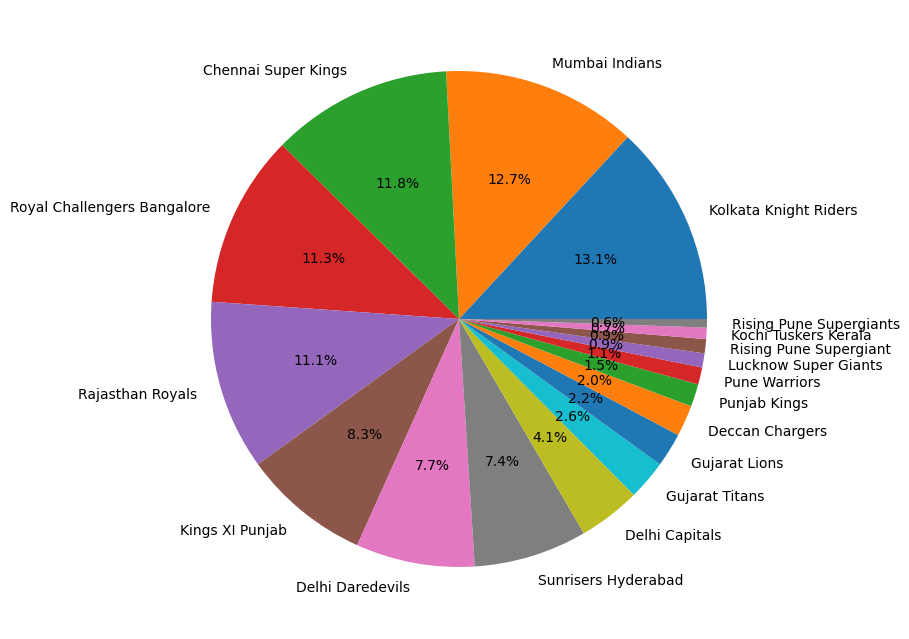

In [ ]:
plt.figure(figsize=(8,10))  
plt.pie(list(batting_second['winner'].value_counts()),labels= list(batting_second['winner'].value_counts().keys()), autopct='%0.1f%%')
plt.show()

### *number of matches played at each season

In [ ]:
df['season'].value_counts() 

season
2013       76
2012       74
2023       74
2022       74
2011       73
2016       60
2014       60
2009/10    60
2021       60
2019       60
2020/21    60
2018       60
2015       59
2017       59
2007/08    58
2009       57
Name: count, dtype: int64